# Programming exercise 2: Time evolution and performance of diagonalization routines

Due on Monday, 27.04.2026, 20h

## Goals of the exercise

In the first exercise we calculated the eigenenergies and eigenfunction of a quantum particle in a one-dimensional potential by representing the wave function on a discrete spatial grid and using `np.eigh()` to diagonalize the Hamiltonian matrix. This time we want to use the obtained eigenfunctions to calculate the time evolution for an arbitrary initial state and compare the performance of different routines for exact diagonalization, also exploring the benefits of sparse matrices.

In [1]:
# load standard libraries

import numpy as np   # standard numerics library

import matplotlib.pyplot as plt # for making plots

import Comp_Quant_Dynam as cqd # our numerics library


### Exercise 1

Calculate the eigenfunctions of the harmonic oscillator on a grid as in programming exercise 1.
Calculate and plot the time evolution for an initial state which is an equal superposition between the lowest two eigenfunctions.
You can animate the plot by completing the code snippet below. Calculate the expectation value $\langle x \rangle$ as a function of time. What is the functional form of the result? Does it match your expectation from the analytical solution?

Hints: Read about broadcasting rules in python. `np.sum()` and matrix multiplication using `@` might be useful.

NameError: name 'x' is not defined

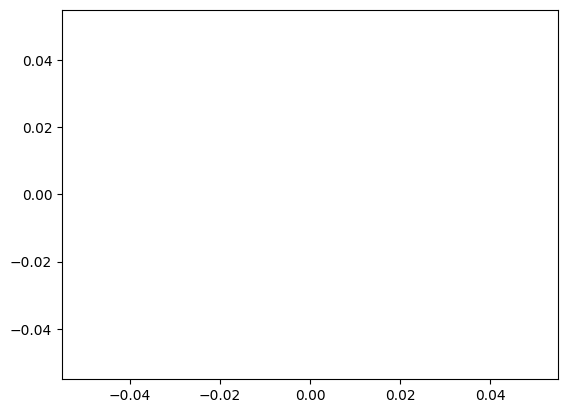

In [2]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
# add more axis specifications here, e.g. axis limits
line, = ax.plot([],[])

def animate(t):
    # y = ... # in this line you should assign current wave function to y at time t, x is the vector of grid points (to be defined!)
    line.set_data(x, y)
    return (line,)

anim = animation.FuncAnimation(fig, animate,
                               frames=np.arange(0,10,0.1), # t-values
                               interval=50, # wait time before displaying new frame in ms
                               blit=True)

HTML(anim.to_jshtml())

- Solve the eigenvalue problem

In [ ]:
from numpy import linalg as LA   # diagonalization and more

- Time evolution of superpositions

- Animate the solutions

- Compute the expectation value of x

### Exercise 2

Calculate the time evolution for arbitrary initial states by decomposing them into a superposition of eigenstates. Test your implementation for a coherent state, i.e. a Gaussian state that is shifted by $x_0$:
$$
\psi_0(x) = \frac{1}{\pi^{1/4}}e^{-(x-x_0)^2/2}
$$
Again, animate the resulting dynamics and also calculate the expectation value of x as a function of time. Describe and interpret your observations.

**Optional**: Play with other initial conditions and other potentials. For example take the double well potential from problem sheet 1 and initialize the system in a state localized on one side. What happens? How do the dynamics depend on the barrier height, i.e. on $\lambda$? Also instructive: Build up the coherent state by taking into account more and more of the eigenstates in the initial superposition and observe what happens to the time evolution.

### Exercise 3

How does the runtime scale with the basis size (number of grid points)? Increase the number of gridpoints from 101 to 1601 in steps of 100 and record the time needed for the exact diagonalization. Plot the runtime as a function of basis size on a double logarithmic scale. Also try out the routine `scipy.linalg.eigh_tridiagonal()` and compare its runtime to `np.eigh()`.

The purpose of this exercise is to sensibilize you that using routines that take into account as much information about the problem to be solved can be a huge advantage in terms of computation time.
The outcome may vary depending on the machine you are using. You are encouraged to explore the documentation of the respective functions and find out what kind of routines they are using underneath.

**Hints**: You can e.g. use the "time" module you can measure the time it takes to do the diagonalization (see code snippet below).

In [ ]:
...
ti = time.time()
#statement I want to time
tf = time.time()
runtimes.append(tf-ti)
...

- Runtime analysis

- Interpretation: ...

### Exercise 4

Since our Hamiltonian matrix contains a lot of zeros it makes sense to use sparse matrices. Hamiltonian matrices of physical systems are very often sparse. If we are only interested in the low lying eigenstates, the Lanczos algorithm provides a very efficient way of obtaining those. Calculate the lowest (e.g. 20) eigenvalues, using sparse matrices. Compare the runtime to your previous implementations. For diagonalising a sparse symmetric matrix, you can use `scipy.sparse.linalg.eigsh()`

- Does the observed scaling of the runtime match your expectations? Again the outcome may depend on the hardware you are using.

**Hints**: For building the Hamiltonian as a sparse matrix, the function `scipy.sparse.diags()` might be helpful. Think about what the "which" option of `scipy.sparse.linalg.eigsh()` should be set to.